##Impact of Dropout Rates on Neural Network Generalisation: A Student Performance Case Study


Training model with dropout rate = 0.0


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training model with dropout rate = 0.2
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step

Training model with dropout rate = 0.5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

Training model with dropout rate = 0.7


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

=== TEST ACCURACY RESULTS ===
Dropout 0.0: 0.671
Dropout 0.2: 0.734
Dropout 0.5: 0.709
Dropout 0.7: 0.646


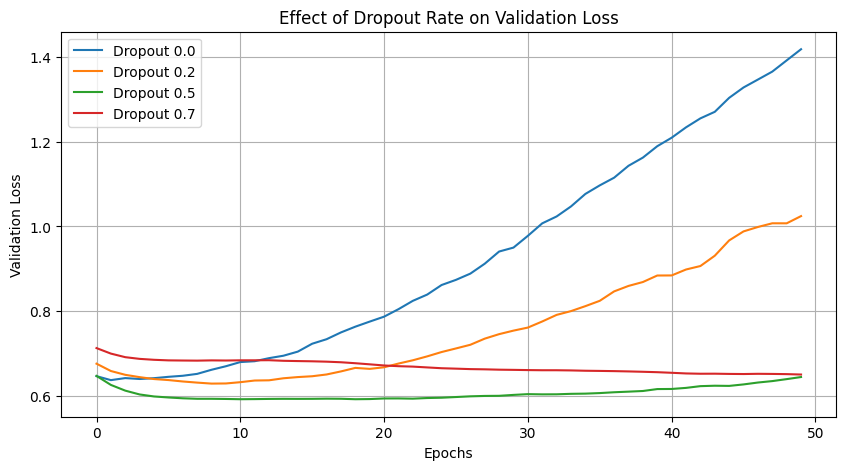

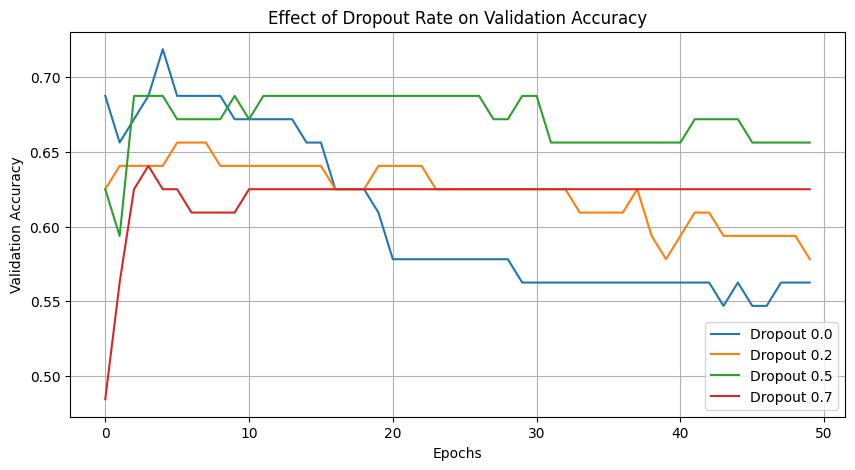

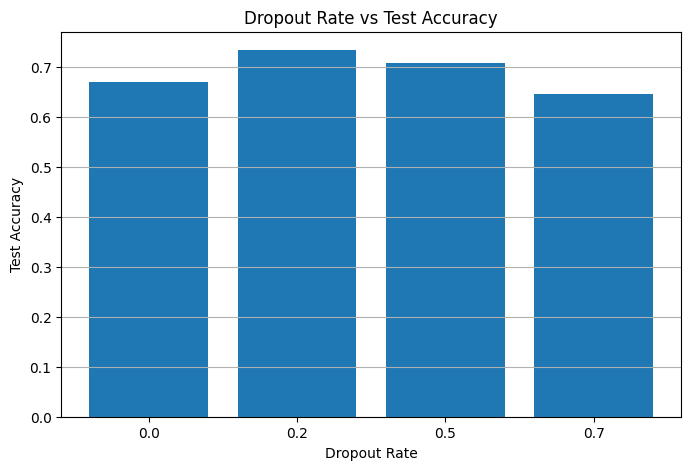

In [3]:
# =========================
# CHALLENGE: Effect of Dropout Rate
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

import requests, zipfile, io

# -------------------------
# 1. Load dataset
# -------------------------
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip"

r = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(r.content))
df = pd.read_csv(z.open("student-mat.csv"), sep=';')

# -------------------------
# 2. Target (pass/fail)
# -------------------------
df['pass'] = (df['G3'] >= 10).astype(int)
df = df.drop(columns=['G1', 'G2', 'G3'])

# -------------------------
# 3. Preprocessing
# -------------------------
df = pd.get_dummies(df, drop_first=True)

X = df.drop('pass', axis=1)
y = df['pass']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -------------------------
# 4. Function to build model
# -------------------------
def build_model(dropout_rate):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))

    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    model.add(Dense(32, activation='relu'))

    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model

# -------------------------
# 5. Train models with different dropout rates
# -------------------------
dropout_rates = [0.0, 0.2, 0.5, 0.7]

histories = {}
accuracies = {}

for rate in dropout_rates:
    print(f"\nTraining model with dropout rate = {rate}")

    model = build_model(rate)

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=50,
        verbose=0
    )

    # Evaluate
    y_pred = (model.predict(X_test) > 0.5).astype(int)
    acc = accuracy_score(y_test, y_pred)

    histories[rate] = history
    accuracies[rate] = acc

# -------------------------
# 6. Print results
# -------------------------
print("\n=== TEST ACCURACY RESULTS ===")
for rate, acc in accuracies.items():
    print(f"Dropout {rate}: {round(acc, 3)}")

# -------------------------
# 7. Plot validation loss
# -------------------------
plt.figure(figsize=(10,5))

for rate in dropout_rates:
    plt.plot(histories[rate].history['val_loss'], label=f"Dropout {rate}")

plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title("Effect of Dropout Rate on Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------
# 8. Plot validation accuracy
# -------------------------
plt.figure(figsize=(10,5))

for rate in dropout_rates:
    plt.plot(histories[rate].history['val_accuracy'], label=f"Dropout {rate}")

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Effect of Dropout Rate on Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------
# 9. Bar chart comparison
# -------------------------
plt.figure(figsize=(8,5))

rates = list(accuracies.keys())
accs = list(accuracies.values())

plt.bar([str(r) for r in rates], accs)
plt.xlabel("Dropout Rate")
plt.ylabel("Test Accuracy")
plt.title("Dropout Rate vs Test Accuracy")
plt.grid(axis='y')

plt.show()

Git:https://github.com/Himasekhar2/dropout-student-performance/tree/main?search=1